In [5]:


#! /usr/bin/env python3
import numpy as np
import emcee
import sys, os
import matplotlib.pyplot as plt
import h5py
from scipy.stats import norm

from multiprocessing import Pool, current_process
import threading
import queue
import time

sys.path.append("../python")
sys.path.append(".")
from canoe import def_species, load_configure
from canoe.snap import def_thermo
from canoe.athena import Mesh, ParameterInput, Outputs, MeshBlock
# from canoe.harp import radiation_band, radiation

def set_atmos_run_RT_concurrent(qH2O: float, 
                     theta: float = 180.0, 
                     RHmax: float=1.0,
                     adlnNH3dlnP: float=0.0,
                     pmin: float = 0.0, 
                     pmax: float = 0.0,
                     jindex: int = 0
                     ):  
    ## construct atmos with a rh limit
    ## jindex is the index of current processer, starting from zero, will add to mb.jst in canoe backend 

    # mb.construct_atmosphere(pin, 320, theta, RHmax, jindex,"pseudo", qH2O, 500)   ## Wrong set

    ## retrieve bottom Temperature with given deep layer potential temperature Theta
    Ts=mb.retrieve_Ts_given_T1bar(pin, 354.8, theta, RHmax, jindex,"dry", qH2O, 500)

    ## construct moist atmosphere with bottom ts
    mb.construct_atmosphere_Ts(pin, 354.8, Ts, RHmax, jindex,"pseudo", qH2O)

    ## modify the top humidity with a increment
    # mb.modify_dlnNH3dlnP_rhmax(adlnNH3dlnP, pmin, pmax, RHmax, jindex) 
    
    ## do radiative transfer
    rad.cal_radiance(mb, mb.k_st, mb.j_st+jindex)
    tb = np.array([0.0] * 4 * nb)
    print(tb.shape)
    for ib in range(nb):

        toa = rad.get_band(ib).get_toa()[0]
        tb[ib * 4 : ib * 4 + 4] = toa
    return tb

def rtm_pseudo_adiabatic(xNH3, theta):
    tb=set_atmos_run_RT_concurrent(xNH3, # NH3.ppmv
                     theta,       # Temperature
                     1.0,         # RH_max_NH3
                     0,        # adlnNH3/dlnP
                     1E-3,         # pmin [Pa]
                     5E5,          # pmax [Pa]
                     0)
    return tb[::4], (tb[::4]-tb[3::4])/(tb[::4])*100

nx2 = 5  ## shall not be less than N_walkers, can be a little greater for safty.

## initialize Canoe
global pin
pin = ParameterInput()
pin.load_from_file("juno_mwr.inp")

vapors = pin.get_string("species", "vapor").split(", ")
clouds = pin.get_string("species", "cloud").split(", ")
tracers = pin.get_string("species", "tracer").split(", ")

def_species(vapors=vapors, clouds=clouds, tracers=tracers)
def_thermo(pin)

config = load_configure("juno_mwr.yaml")
# print(pin.get_real("problem", "qH2O.ppmv"))

pin.set_boolean("job","verbose", False)

print(pin.get_string("mesh","nx2"))
pin.set_string("mesh","nx2", f"{nx2}")

print(pin.get_string("mesh","nx2"))

# pin.set_Real("radiation","outdir","(0,) (15,) (30,) (45,)")
print(pin.get_string("radiation","outdir"))

# exit()

mesh = Mesh(pin)
mesh.initialize(pin)

global mb, rad, nb
mb = mesh.meshblock(0)
rad = mb.get_rad()
nb = rad.get_num_bands()
print(f"nb={nb}")
# Create a grid for reflectance at band 3 and band 6
xNH3s= [0, 500, 1000,1500,2000,2500,3000,3500,4000,4500,5000,5500,6000] # 50 points for band 3 reflectance
# xNH3s   = [200,250,300,350,400,450,500,550] # 50 points for band 3 reflectance
Thetas  = [150,155,160,165,170,175,180,185,190]
# Initialize arrays for TBs and LDs with the same dimensions
TBs = np.zeros((len(xNH3s), len(Thetas),6), dtype=np.float32)  # Radiances array
LDs = np.zeros((len(xNH3s), len(Thetas),6), dtype=np.float32)  # Lookup table array


for ix, xnh3 in enumerate(xNH3s):
    for it, theta in enumerate(Thetas):
        print(xnh3,theta)
        TBs[ix,it,:], LDs[ix,it,:] =rtm_pseudo_adiabatic(xnh3, theta)
        
with h5py.File('model_LUT_TB_LD_theta_xH2O.h5', 'w') as f:
    f.create_dataset('TBs', data=TBs)
    f.create_dataset('LDs', data=LDs)




RuntimeError: 
*******************************************************************************
RuntimeError thrown by IndexMap:
IndexMap has been initialized
*******************************************************************************


In [2]:

import h5py
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

mwr_coeff = "../../../mwr_polar_coefficients.csv"
df = pd.read_csv(mwr_coeff, header=None, names=["channel", "c0", "c1", "c2"])
obs = df["c0"].values
obsLD=[13.2, 10.0, 6.9, 5.9, 4.5, 1.4]  

print("obsTB:", obs)
print("obsLD:", obsLD)

obsTB: [908.46972469 479.08699872 338.75165919 251.70653583 192.47340754
 141.07444985]
obsLD: [13.2, 10.0, 6.9, 5.9, 4.5, 1.4]


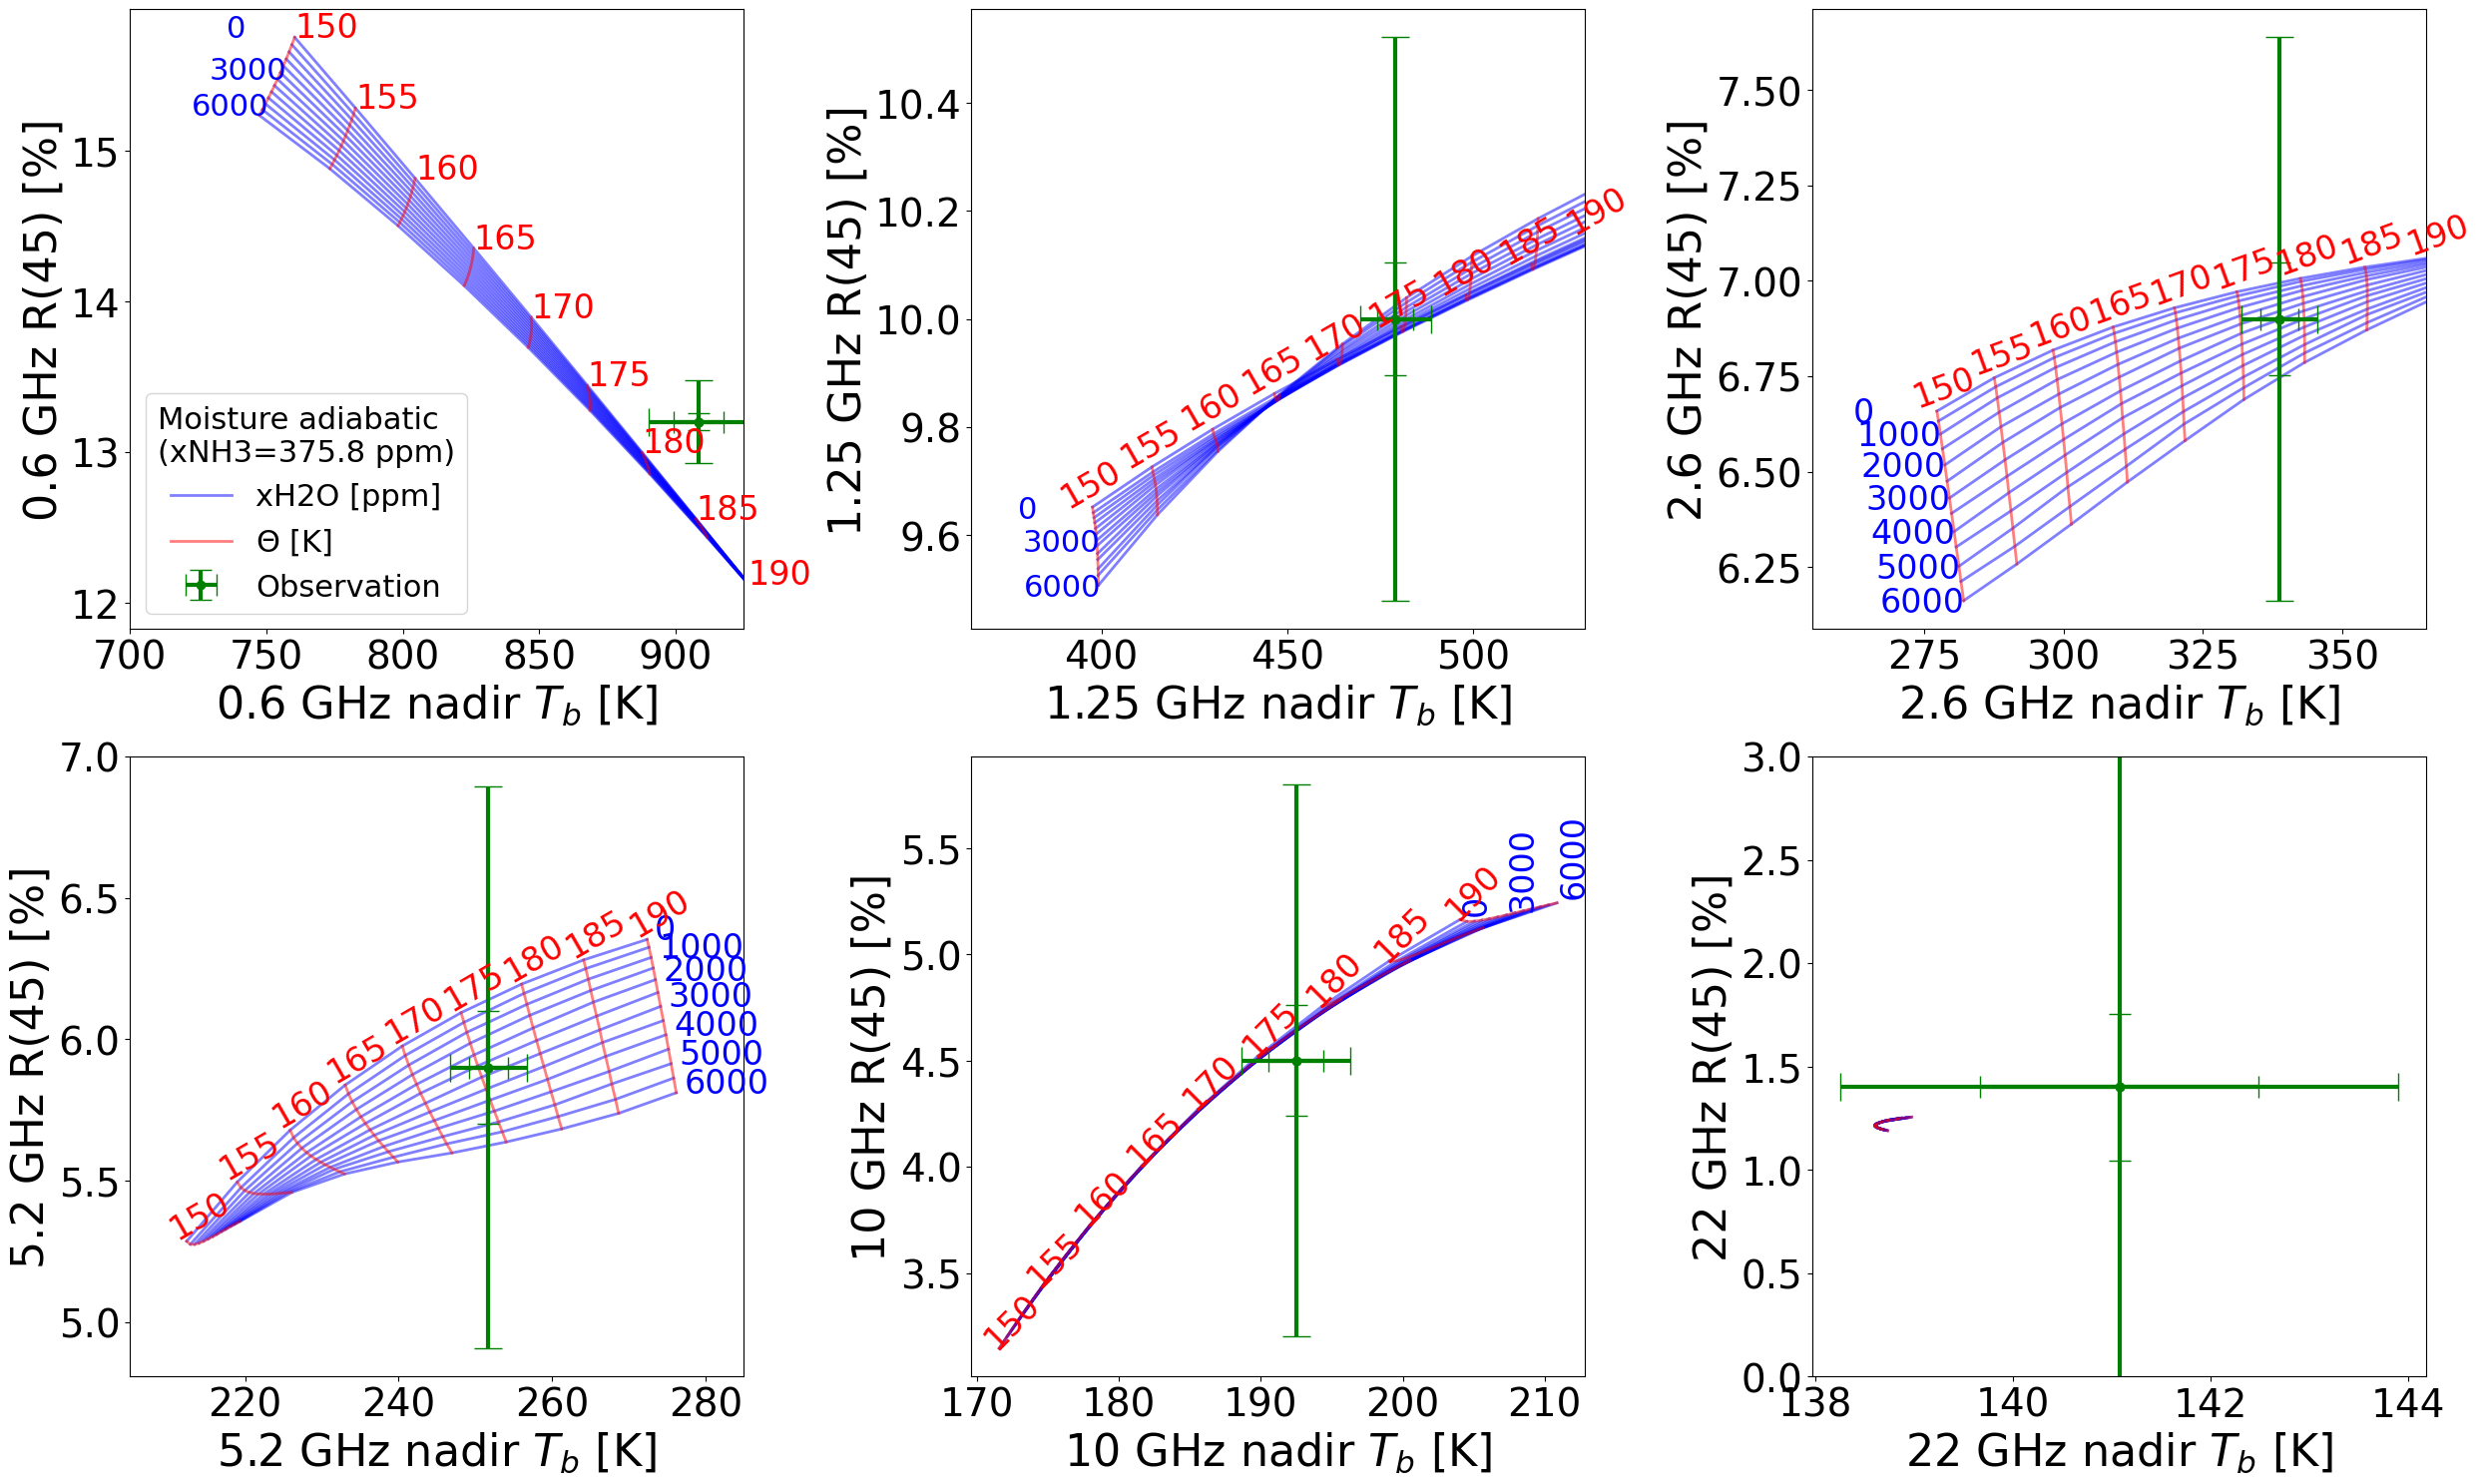

In [3]:
#! /usr/bin/env python3
import numpy as np
import emcee
import sys, os
import matplotlib.pyplot as plt
import h5py
from scipy.stats import norm


with h5py.File("model_LUT_TB_LD_theta_xH2O.h5","r") as f:
    TBs=f["TBs"][:]
    LDs=f["LDs"][:]


# with h5py.File("model_LUT_TB_LD_dry.h5","r") as f:
#     TBs_dry=f["TBs"][:]
#     LDs_dry=f["LDs"][:]
    
# print(LDs)
xNH3s= [0, 500, 1000,1500,2000,2500,3000,3500,4000,4500,5000,5500,6000] # 50 points for band 3 reflectance
# xNH3s   = [200,250,300,350,400,450,500,550] # 50 points for band 3 reflectance
Thetas  = [150,155,160,165,170,175,180,185,190]
# Plot the cloud optical depth as contour lines


fig, ax = plt.subplots(2, 3, figsize=(25, 15))  # 2 rows, 3 columns,WW with a custom figure size

fontsize=24

axs=ax.flatten()
for ich, ax in enumerate(axs):
    id=[0,0,0,-1,-1,-1][ich]

    for ix, xnh3 in enumerate(xNH3s):
        if ix==0:
            ax.plot(TBs[ix,:,ich], LDs[ix,:,ich],color="Blue",alpha=0.5, linewidth=2,label="xH2O [ppm]")
        else:
            ax.plot(TBs[ix,:,ich], LDs[ix,:,ich],color="Blue",alpha=0.5, linewidth=2)

        if ix%6==0:
            if ich==0:
                ax.text(TBs[ix, id,ich]-25, LDs[ix, id,ich], f"{xnh3}", rotation=0, color="Blue",fontsize=22)
            elif ich==1:
                ax.text(TBs[ix, id,ich]-20, LDs[ix, id,ich]-0.02, f"{xnh3}", rotation=0, color="Blue",fontsize=22)
        if ich==4 and ix%6==0:
                ax.text(TBs[ix, id,ich], LDs[ix, id,ich]*1.01, f"{xnh3}", rotation=90, color="Blue",fontsize=fontsize)

        if ix%2==0:
            # if ich==0:
            #     ax.text(TBs[ix, id,ich], LDs[ix, id,ich]+0.1, f"{xnh3}", rotation=0, color="Blue")
            # if ich==1:
                # ax.text(TBs[ix, id,ich]-20, LDs[ix, id,ich], f"{xnh3}", rotation=0, color="Blue")
            if ich==2:
                ax.text(TBs[ix, id,ich]-15, LDs[ix, id,ich]-0.03, f"{xnh3}", rotation=0, color="Blue",fontsize=fontsize)
            if ich==3:
                ax.text(TBs[ix, id,ich]+1, LDs[ix, id,ich], f"{xnh3}", rotation=0, color="Blue",fontsize=fontsize)


    for it, theta in enumerate(Thetas):
        if it==0:
            ax.plot(TBs[:,it,ich], LDs[:,it,ich],color="red",alpha=0.5, linewidth=2,label=r"$\Theta$ [K]")
        else:
            ax.plot(TBs[:,it,ich], LDs[:,it,ich],color="red",alpha=0.5, linewidth=2)
        if ich==0:
            ax.text(TBs[0,it,ich], LDs[0,it,ich], f"{theta:02d}",color="red",fontsize=fontsize)
        elif ich==1:
            ax.text(TBs[0,it,ich]-10, LDs[0,it,ich], f"{theta:02d}", rotation=30,color="red",fontsize=fontsize)
        elif ich==2:
            ax.text(TBs[0,it,ich]-5, LDs[0,it,ich]+0.01, f"{theta:02d}", rotation=20,color="red",fontsize=fontsize)
        elif ich==3:
            ax.text(TBs[0,it,ich]-3, LDs[0,it,ich]+0.01, f"{theta:02d}", rotation=30,color="red",fontsize=fontsize)
        elif ich==4:
            ax.text(TBs[0,it,ich]-1.5, LDs[0,it,ich], f"{theta:02d}", rotation=45,color="red",fontsize=fontsize)

    LD=obsLD[ich]
    ax.errorbar(obs[ich],LD, xerr=0.01*obs[ich], yerr=0.5/obs[ich]*100, fmt='o', linewidth=3,capsize=8, label="Observation", color='green')
    ax.errorbar(obs[ich],LD, xerr=0.02*obs[ich], yerr=2.5/obs[ich]*100, fmt='o', linewidth=3,capsize=10, color='green')


    # Add labels and title
    GHz=[0.6,1.25, 2.6, 5.2, 10, 22]
    ax.set_xlabel(fr'{GHz[ich]} GHz nadir $T_b$ [K]', fontsize=32)
    ax.set_ylabel(fr'{GHz[ich]} GHz R(45) [%]', fontsize=32)
    # ax.set_title(f'Channel {ich+1}')

    ax.tick_params(axis='x', labelsize=28)  # Change 14 to any desired font size
    ax.tick_params(axis='y', labelsize=28)  # Change 14 to any desired font size

    # ax.text(0.95, 0.95, chr(97+ich), transform=ax.transAxes, fontsize=36, fontweight='bold', va='top', ha='right')
axs[0].legend(title="Dry adiabatic\n(xH2O=2500 ppm)", fontsize=28, title_fontsize=28)

# for ich, ax in enumerate(axs):


# axs[0].text(880,14, r"$\Theta$ [K]" , color="Red",fontsize=12)
# axs[1].text(450, 10.5, r"$\Theta$ [K]", color="red",fontsize=12, rotation=30)
# axs[2].text(300, 7, r"$\Theta$ [K]", color="red",fontsize=12, rotation=30)
# axs[3].text(245, 6.22, r"$\Theta$ [K]", color="red",fontsize=12, rotation=30)
# axs[4].text(190,4.3, r"$\Theta$ [K]", color="red",fontsize=12, rotation=0)
# axs[5].text(138.8,1.24, r"$\Theta$ [K]", color="red",fontsize=12, rotation=0)


# axs[0].text(760, 16, "xH2O [ppm]", color="Blue",fontsize=12)
# axs[1].text(370,9.95, "xH2O [ppm]", color="Blue",fontsize=12, rotation=80)
# axs[2].text(260,6.45, "xH2O [ppm]", color="Blue",fontsize=12, rotation=85)
# axs[3].text(280,5.9, "xH2O [ppm]", color="Blue",fontsize=12, rotation=85)

# axs[0].set_ylim(11.5,16)
axs[0].set_xlim(700,925)
axs[1].set_xlim(365,530)
# axs[2].set_xlim(265,380)
axs[2].set_xlim(255,365)
axs[3].set_xlim(205,285)
axs[5].set_ylim(0,3)

axs[3].set_yticks([5,5.5,6,6.5,7])


# axs[3].set_ylim(5.35,6.5)
axs[0].legend(title="Moisture adiabatic\n(xNH3=375.8 ppm)",fontsize=22, title_fontsize=22)
# axs[5].set_xticks([138.6,138.7,138.8,138.9,139])
plt.tight_layout()
# Display the plot
plt.savefig("Extend_LUT_moist_adb.pdf", dpi=300)
plt.show()


In [1]:


#! /usr/bin/env python3
import numpy as np
import emcee
import sys, os
import matplotlib.pyplot as plt
import h5py
from scipy.stats import norm

from multiprocessing import Pool, current_process
import threading
import queue
import time

sys.path.append("../python")
sys.path.append(".")
from canoe import def_species, load_configure
from canoe.snap import def_thermo
from canoe.athena import Mesh, ParameterInput, Outputs, MeshBlock
# from canoe.harp import radiation_band, radiation

def set_atmos_run_RT_concurrent(xNH3: float, 
                     xH2O: float = 180.0, 
                     RHmax: float=1.0,
                     adlnNH3dlnP: float=0.0,
                     pmin: float = 0.0, 
                     pmax: float = 0.0,
                     jindex: int = 0
                     ):  
    ## construct atmos with a rh limit
    ## jindex is the index of current processer, starting from zero, will add to mb.jst in canoe backend 

    # mb.construct_atmosphere(pin, 320, theta, RHmax, jindex,"pseudo", qH2O, 500)   ## Wrong set

    ## retrieve bottom Temperature with given deep layer potential temperature Theta
    Ts=mb.retrieve_Ts_given_T1bar(pin, xNH3, 175.7, RHmax, jindex,"dry", xH2O,500)

    ## construct moist atmosphere with bottom ts
    mb.construct_atmosphere_Ts(pin, xNH3, Ts, RHmax, jindex,"pseudo", xH2O)

    ## modify the top humidity with a increment
    # mb.modify_dlnNH3dlnP_rhmax(adlnNH3dlnP, pmin, pmax, RHmax, jindex) 
    
    ## do radiative transfer
    rad.cal_radiance(mb, mb.k_st, mb.j_st+jindex)
    tb = np.array([0.0] * 4 * nb)
    print(tb.shape)
    for ib in range(nb):

        toa = rad.get_band(ib).get_toa()[0]
        tb[ib * 4 : ib * 4 + 4] = toa
    return tb

def rtm_pseudo_adiabatic(xNH3, xH2O):
    tb=set_atmos_run_RT_concurrent(xNH3, # NH3.ppmv
                     xH2O,       # Temperature
                     1.0,         # RH_max_NH3
                     0,        # adlnNH3/dlnP
                     1E-3,         # pmin [Pa]
                     5E5,          # pmax [Pa]
                     0)
    return tb[::4], (tb[::4]-tb[3::4])/(tb[::4])*100

nx2 = 5  ## shall not be less than N_walkers, can be a little greater for safty.

## initialize Canoe
global pin
pin = ParameterInput()
pin.load_from_file("juno_mwr.inp")

vapors = pin.get_string("species", "vapor").split(", ")
clouds = pin.get_string("species", "cloud").split(", ")
tracers = pin.get_string("species", "tracer").split(", ")

def_species(vapors=vapors, clouds=clouds, tracers=tracers)
def_thermo(pin)

config = load_configure("juno_mwr.yaml")
# print(pin.get_real("problem", "qH2O.ppmv"))

pin.set_boolean("job","verbose", False)

print(pin.get_string("mesh","nx2"))
pin.set_string("mesh","nx2", f"{nx2}")

print(pin.get_string("mesh","nx2"))

# pin.set_Real("radiation","outdir","(0,) (15,) (30,) (45,)")
print(pin.get_string("radiation","outdir"))

# exit()

mesh = Mesh(pin)
mesh.initialize(pin)

global mb, rad, nb
mb = mesh.meshblock(0)
rad = mb.get_rad()
nb = rad.get_num_bands()
print(f"nb={nb}")
# Create a grid for reflectance at band 3 and band 6
xH2Os   = [0, 500, 1000,1500,2000,2500,3000,3500,4000,4500,5000,5500,6000] # 50 points for band 3 reflectance
xNH3s   = [340, 345, 350, 355, 360, 365, 370,375] # 50 points for band 3 reflectance
Thetas  = [150,155,160,165,170,175,180,185,190]
# Initialize arrays for TBs and LDs with the same dimensions
TBs = np.zeros((len(xNH3s), len(xH2Os),6), dtype=np.float32)  # Radiances array
LDs = np.zeros((len(xNH3s), len(xH2Os),6), dtype=np.float32)  # Lookup table array


for ix, xnh3 in enumerate(xNH3s):
    for it, xh2o in enumerate(xH2Os):
        print(xnh3,xh2o)
        TBs[ix,it,:], LDs[ix,it,:] =rtm_pseudo_adiabatic(xnh3, xh2o)
        print(TBs[ix,it,:], LDs[ix,it,:])
        
with h5py.File('model_LUT_TB_LD_xNH3_xH2O.h5', 'w') as f:
    f.create_dataset('TBs', data=TBs)
    f.create_dataset('LDs', data=LDs)




5Log, "2026-03-10 15:45:05",        canoe, 1., "Installing monitor canoe"

5
(0,) (15,) (30,) (45,)
Log, "2026-03-10 15:45:05",        canoe, 1.1., "Initialize IndexMap"
Log, "2026-03-10 15:45:05",         snap, 3., "Installing monitor snap"
Log, "2026-03-10 15:45:05",         snap, 3.1., "Initialize Thermodynamics"
Log, "2026-03-10 15:45:05",         snap, 3.1.1., "Enrolling vapor functions"
Log, "2026-03-10 15:45:05",         snap, 3.1.1.1., "Enrolling H2O vapor pressures"
Log, "2026-03-10 15:45:05",         snap, 3.1.2.1., "Enrolling NH3 vapor pressures"
nb=6
340 0
Log, "2026-03-10 15:45:05",         snap, 4.1., "Initialize Decomposition"
Log, "2026-03-10 15:45:05",         snap, 5.1., "Initialize ImplicitSolver"
Log, "2026-03-10 15:45:05", microphysics, 7., "Installing monitor microphysics"
Log, "2026-03-10 15:45:05", microphysics, 7.1., "Initialize Microphysics"
Log, "2026-03-10 15:45:05",         harp, 9., "Installing monitor harp"
Log, "2026-03-10 15:45:05",         harp, 9.1., 

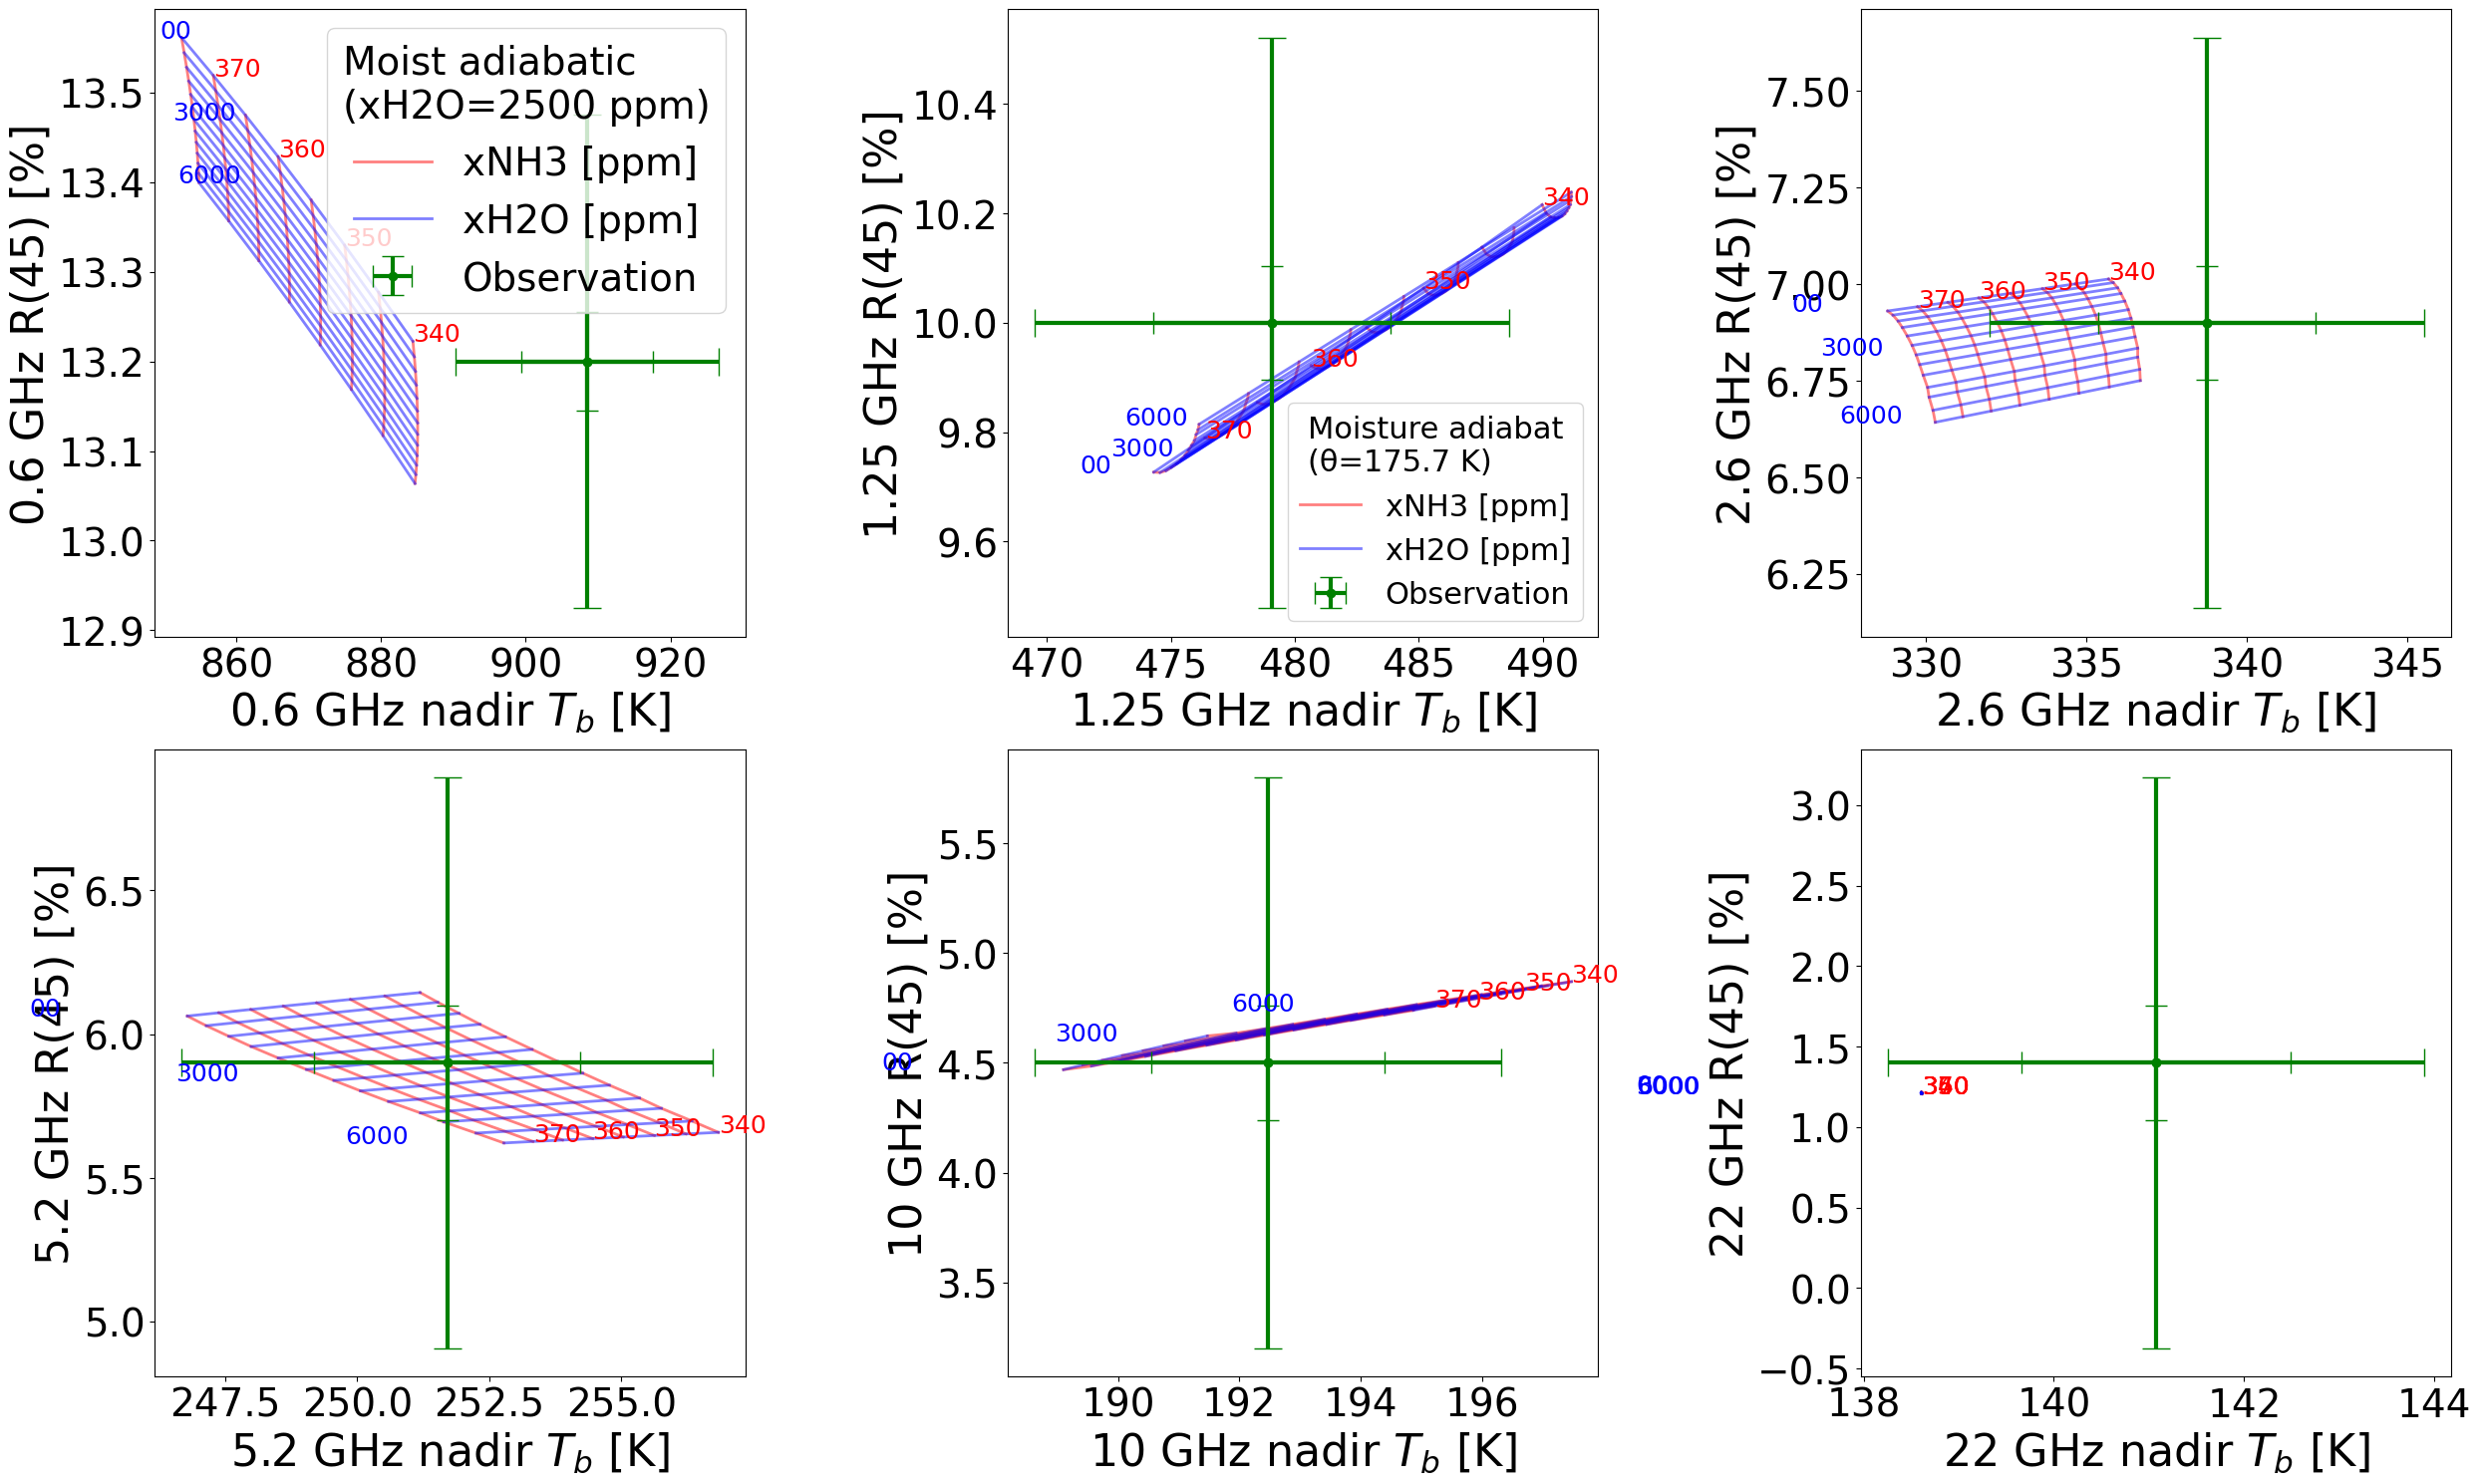

In [11]:
#! /usr/bin/env python3
import numpy as np
import emcee
import sys, os
import matplotlib.pyplot as plt
import h5py
from scipy.stats import norm


with h5py.File("model_LUT_TB_LD_xNH3_xH2O.h5","r") as f:
    TBs=f["TBs"][:]
    LDs=f["LDs"][:]


# with h5py.File("model_LUT_TB_LD_dry.h5","r") as f:
#     TBs_dry=f["TBs"][:]
#     LDs_dry=f["LDs"][:]
    
# print(LDs)
Thetas= [0, 500, 1000,1500,2000,2500,3000,3500,4000,4500,5000,5500,6000] # 50 points for band 3 reflectance
xNH3s   = [340, 345, 350, 355, 360, 365, 370,375] # 50 points for band 3 reflectance
# Thetas  = [150,155,160,165,170,175,180,185,190]
# Plot the cloud optical depth as contour lines


fig, ax = plt.subplots(2, 3, figsize=(25, 15))  # 2 rows, 3 columns,WW with a custom figure size

fontsize=18

axs=ax.flatten()
for ich, ax in enumerate(axs):
    id=[0,0,0,-1,-1,-1][ich]

    for ix, xnh3 in enumerate(xNH3s):
        if ix==0:
            ax.plot(TBs[ix,:,ich], LDs[ix,:,ich],color="r",alpha=0.5, linewidth=2,label="xNH3 [ppm]")
        else:
            ax.plot(TBs[ix,:,ich], LDs[ix,:,ich],color="r",alpha=0.5, linewidth=2)

        # if ix%6==0:
        #     if ich==0:
        #         ax.text(TBs[ix, id,ich], LDs[ix, id,ich], f"{xnh3}", rotation=0, color="r",fontsize=22)
        #     elif ich==1:
        #         ax.text(TBs[ix, id,ich], LDs[ix, id,ich], f"{xnh3}", rotation=0, color="r",fontsize=22)
        # if ich==4 and ix%6==0:
        #         ax.text(TBs[ix, id,ich], LDs[ix, id,ich], f"{xnh3}", rotation=90, color="r",fontsize=fontsize)

        if ix%2==0:
            # if ich==0:
            #     ax.text(TBs[ix, id,ich], LDs[ix, id,ich]+0.1, f"{xnh3}", rotation=0, color="Blue")
            # if ich==1:
                # ax.text(TBs[ix, id,ich]-20, LDs[ix, id,ich], f"{xnh3}", rotation=0, color="Blue")
            # if ich==2:
                ax.text(TBs[ix, id,ich], LDs[ix, id,ich], f"{xnh3}", rotation=0, color="r",fontsize=fontsize)
            # if ich==3:
            #     ax.text(TBs[ix, id,ich], LDs[ix, id,ich], f"{xnh3}", rotation=0, color="r",fontsize=fontsize)


    for it, theta in enumerate(Thetas):
        if it==0:
            ax.plot(TBs[:,it,ich], LDs[:,it,ich],color="b",alpha=0.5, linewidth=2,label="xH2O [ppm]")
        else:
            ax.plot(TBs[:,it,ich], LDs[:,it,ich],color="b",alpha=0.5, linewidth=2)

        if it%6==0:
            ax.text(TBs[-1,it,ich]-3, LDs[-1,it,ich], f"{theta:02d}",color="b",fontsize=fontsize)
        

        # elif ich==1:
        #     ax.text(TBs[0,it,ich], LDs[0,it,ich], f"{theta:02d}", rotation=30,color="b",fontsize=fontsize)
        # elif ich==2:
        #     ax.text(TBs[0,it,ich], LDs[0,it,ich], f"{theta:02d}", rotation=20,color="b",fontsize=fontsize)
        # elif ich==3:
        #     ax.text(TBs[0,it,ich], LDs[0,it,ich], f"{theta:02d}", rotation=30,color="b",fontsize=fontsize)
        # elif ich==4:
        #     ax.text(TBs[0,it,ich], LDs[0,it,ich], f"{theta:02d}", rotation=45,color="b",fontsize=fontsize)

    LD=obsLD[ich]
    ax.errorbar(obs[ich],LD, xerr=0.01*obs[ich], yerr=0.5/obs[ich]*100, fmt='o', linewidth=3,capsize=8, label="Observation", color='green')
    ax.errorbar(obs[ich],LD, xerr=0.02*obs[ich], yerr=2.5/obs[ich]*100, fmt='o', linewidth=3,capsize=10, color='green')


    # Add labels and title
    GHz=[0.6,1.25, 2.6, 5.2, 10, 22]
    ax.set_xlabel(fr'{GHz[ich]} GHz nadir $T_b$ [K]', fontsize=32)
    ax.set_ylabel(fr'{GHz[ich]} GHz R(45) [%]', fontsize=32)
    # ax.set_title(f'Channel {ich+1}')

    ax.tick_params(axis='x', labelsize=28)  # Change 14 to any desired font size
    ax.tick_params(axis='y', labelsize=28)  # Change 14 to any desired font size

    # ax.text(0.95, 0.95, chr(97+ich), transform=ax.transAxes, fontsize=36, fontweight='bold', va='top', ha='right')
axs[0].legend(title="Moist adiabatic\n(xH2O=2500 ppm)", fontsize=28, title_fontsize=28)

# for ich, ax in enumerate(axs):


# axs[0].text(880,14, r"$\Theta$ [K]" , color="Red",fontsize=12)
# axs[1].text(450, 10.5, r"$\Theta$ [K]", color="red",fontsize=12, rotation=30)
# axs[2].text(300, 7, r"$\Theta$ [K]", color="red",fontsize=12, rotation=30)
# axs[3].text(245, 6.22, r"$\Theta$ [K]", color="red",fontsize=12, rotation=30)
# axs[4].text(190,4.3, r"$\Theta$ [K]", color="red",fontsize=12, rotation=0)
# axs[5].text(138.8,1.24, r"$\Theta$ [K]", color="red",fontsize=12, rotation=0)


# axs[0].text(760, 16, "xH2O [ppm]", color="Blue",fontsize=12)
# axs[1].text(370,9.95, "xH2O [ppm]", color="Blue",fontsize=12, rotation=80)
# axs[2].text(260,6.45, "xH2O [ppm]", color="Blue",fontsize=12, rotation=85)
# axs[3].text(280,5.9, "xH2O [ppm]", color="Blue",fontsize=12, rotation=85)

# axs[0].set_ylim(11.5,16)
# axs[0].set_xlim(700,925)
# axs[1].set_xlim(365,530)
# # axs[2].set_xlim(265,380)
# axs[2].set_xlim(255,365)
# axs[3].set_xlim(205,285)
# axs[5].set_ylim(0,3)

# axs[3].set_yticks([5,5.5,6,6.5,7])


# axs[3].set_ylim(5.35,6.5)
axs[1].legend(title="Moisture adiabat\n(θ=175.7 K)",fontsize=22, title_fontsize=22)
# axs[5].set_xticks([138.6,138.7,138.8,138.9,139])
plt.tight_layout()
# Display the plot
plt.savefig("Extend_LUT_moist_XNH3_XH2O.pdf", dpi=300)
plt.show()
